# Getting Started with Pandas
## What is Pandas?
Pandas is a powerful, open-source Python library used for data manipulation,
cleaning, and analysis. It provides two main data structures:
* Series: A one-dimensional labeled array
* DataFrame: A two-dimensional labeled table (like an Excel sheet or SQL table)
Pandas makes working with structured data fast, expressive, and flexible.
* If you’re working with tables, spreadsheets, or CSVs in Python—Pandas is
your best friend.

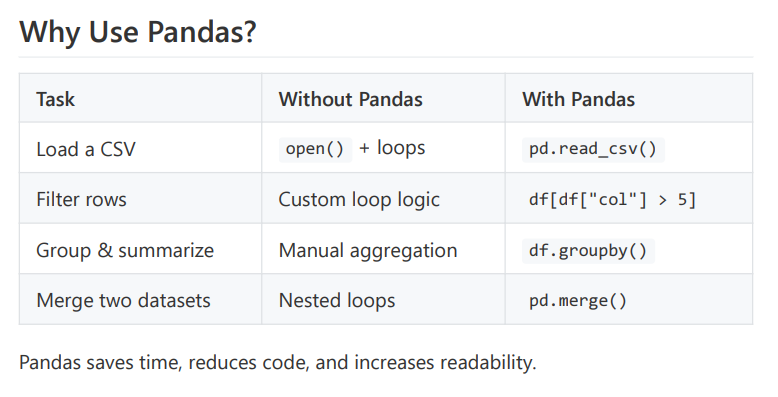


In [1]:
#How to install pandas
# pip install pandas

#How to import pandas
import pandas as pd

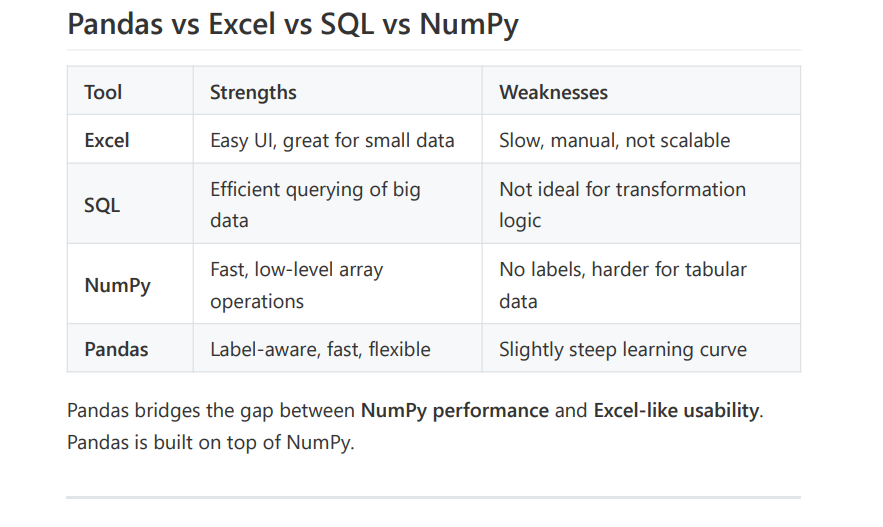

## Summary
* Use Pandas when working with structured data.
* It's the Swiss Army knife of data science.

# --------------- Core Data Structures in Pandas ----------------

## Pandas is built on two main data structures:
* 1.Series → One-dimensional (like a single column in Excel)
* 2.DataFrame → Two-dimensional (like a full spreadsheet or SQL table)

In [2]:
#1D -> Series

s = pd.Series([1,2,3,4])
print(s)

0    1
1    2
2    3
3    4
dtype: int64


In [12]:
# 2D array -> DataFrame (row,column)
data = {
    "Name" : ["Aditya","Nirmit","Amil"],
    "Age" : [12,34,99],
    "Graduate" : [True,False,False]
}

df = pd.DataFrame(data)

print(df.iloc[0])
print(df.index)
#You can change index

df.index = ["a","b","c"]

print(df.index)
print(df.columns)
#You can change column names
df.columns = ["name","age","pass"]

print(df.columns)
print(df)

Name        Aditya
Age             12
Graduate      True
Name: 0, dtype: object
RangeIndex(start=0, stop=3, step=1)
Index(['a', 'b', 'c'], dtype='object')
Index(['Name', 'Age', 'Graduate'], dtype='object')
Index(['name', 'age', 'pass'], dtype='object')
     name  age   pass
a  Aditya   12   True
b  Nirmit   34  False
c    Amil   99  False


# --------------- Creating DataFrames ----------------


In [13]:
#from python lists

data = [
    ["Alice", 25],
    ["Bob", 30],
    ["Charlie", 35]
]
df = pd.DataFrame(data,columns=["name","age"])
print(df)

      name  age
0    Alice   25
1      Bob   30
2  Charlie   35


In [14]:
#From dictionary of list

data = {
    "Name" : ["Aditya","Nirmit","Amil"],
    "Age" : [12,34,99],
    "Graduate" : [True,False,False]
}
df = pd.DataFrame(data)

In [22]:
#From numpy arrays
import numpy as np

arr = np.array([[23,22,33,45],[99,69,90,93]])
arr = arr.T

df = pd.DataFrame(arr,columns=['age','marks'])
df['name'] = ['Aditya',"Ramkam","Alnahor","Manual"]

print(df)

   age  marks     name
0   23     99   Aditya
1   22     69   Ramkam
2   33     90  Alnahor
3   45     93   Manual


In [ ]:
#From files

#Csv file
# df = pd.read_csv("data.csv")

# Excel file
# df = pd.read_excel("data.xlsx")

# Json
# df = pd.read_json("data.json")


In [23]:
#From sql database
'''import sqlite3

conn = sqlite3.connect("mydb.sqlite")

df = pd.read_sql("SELECT * FROM users", conn)
'''

'import sqlite3\nconn = sqlite3.connect("mydb.sqlite")\ndf = pd.read_sql("SELECT * FROM users", conn)\n'

In [25]:
#From url
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
print(df)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


## EDA (Exploratory Data Analysis)

In [27]:
df.head() # First 5 rows
df.tail() # Last 5 rows
df.info() # Column info: types, non-nulls
df.describe() # Stats for numeric columns
df.columns # List of column names
df.shape # (rows, columns)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null   

# ------------- Data Selection & Filtering ---------------

## Selecting the right rows and columns is the first step in analyzing any dataset.
Pandas gives you several powerful ways to do this.

In [30]:
# Selecting columns

#single column
df['smoker']

#Multiple columns
print(df[['day','sex','tip']])

      day     sex   tip
0     Sun  Female  1.01
1     Sun    Male  1.66
2     Sun    Male  3.50
3     Sun    Male  3.31
4     Sun  Female  3.61
..    ...     ...   ...
239   Sat    Male  5.92
240   Sat  Female  2.00
241   Sat    Male  2.00
242   Sat    Male  1.75
243  Thur  Female  3.00

[244 rows x 3 columns]


In [33]:
#Using loc , iloc
df.loc[0, "tip"] # Value at row 0, column 'Name'
df.iloc[0, 1] # Value at row 0, column at index 1

df.loc[0:2, ["time", "size"]] # Rows 0 to 2, selected columns
df.iloc[0:2, 0:2] # Rows and cols by index position

,total_bill,tip
0,16.99,1.01
1,10.34,1.66


In [34]:
#Using it and iat for faster single element access
df.at[0, "sex"] # Fast label-based access
df.iat[0, 1] # Fast position-based access

np.float64(1.01)

## Filtering with conditions

In [36]:
#Filterning with conditions

df[df['sex']=='Male']

#Multiple conditions

df[(df['day'] == 'Sun') & (df['total_bill'] >= 25)]

,total_bill,tip,sex,smoker,day,time,size
5,25.29,4.71,Male,No,Sun,Dinner,4
7,26.88,3.12,Male,No,Sun,Dinner,4
11,35.26,5.00,Female,No,Sun,Dinner,4
44,30.40,5.60,Male,No,Sun,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
48,28.55,2.05,Male,No,Sun,Dinner,3
52,34.81,5.20,Female,No,Sun,Dinner,4
54,25.56,4.34,Male,No,Sun,Dinner,4
112,38.07,4.00,Male,No,Sun,Dinner,3
114,25.71,4.00,Female,No,Sun,Dinner,3


## Querying with .query()

In [38]:
#This is a cleaner, SQL-like way to filter:

df.query("sex == 'Male' and day == 'Sun'")

#dynamic column name
col = 'tip'
df.query(f"{col} > 4.5")

,total_bill,tip,sex,smoker,day,time,size
5,25.29,4.71,Male,No,Sun,Dinner,4
11,35.26,5.00,Female,No,Sun,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
39,31.27,5.00,Male,No,Sat,Dinner,3
44,30.40,5.60,Male,No,Sun,Dinner,4
46,22.23,5.00,Male,No,Sun,Dinner,2
47,32.40,6.00,Male,No,Sun,Dinner,4
52,34.81,5.20,Female,No,Sun,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
73,25.28,5.00,Female,Yes,Sat,Dinner,2


## .query() returns a copy, not a view
The result is a new DataFrame. Changes won't affect the original unless reassigned:

# --------------- Data Cleaning & Preprocessing ---------------

## Handling Missing Values

In [41]:
#Check null values

df.isnull()
df.isnull().sum()

#Drop missing data
df.dropna()              # Drop rows with *any* missing values
df.dropna(axis=1)        # Drop columns with missing values (Use carefully)

#Fill missing data
df.fillna(0)
df['tip'].fillna(df['tip'].mean())
df.ffill()
df.bfill()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [42]:
#Detecting & Removing Duplicates
df.duplicated()
df.drop_duplicates()
df.drop_duplicates(subset=['tip','sex'])

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3


## string Operations with .str

In [ ]:
df["time"].str.lower() # Converts all names to lowercase.
df["day"].str.contains("Mon", case=False) # Checks if 'delhi' is in the city name, case-insensitive.
# df["Email"].str.split("@") # Outputs a pandas Series where each element is a list of strings (the split parts). This is where a Python list comes into play, but the outer object is still a pandas Series.

## Type Conversions with .astype()

In [ ]:
# df["Age"] = df["Age"].astype(int)
# df["Date"] = pd.to_datetime(df["Date"])
# df["Category"] = df["Category"].astype("category")

## Applying Functions


In [53]:
#Apply function
df['holiday'] = df['day'].apply(lambda x : "holiday" if x in ['Sun','Sat'] else "working")

#map function
gender = {'Male' : 0, "Female" : 1}

df['sex'] = df['sex'].map(gender)

#.replace()
days = {
    'Sun' : 'Sunday',
    'Mon' : 'Monday',
    'Tue' : 'Tuesday',
    'Wed' : 'Wednesday',
    'Thu' : 'Thursday',
    'Fri' : 'Friday',
    'Sat' : 'Saturday'
}

df['full_name_day'] = df['day'].replace(days)

,sex
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
239,NaN
240,NaN
241,NaN
242,NaN


Here is your content **cleanly formatted and styled** without changing any information. I only improved **structure, spacing, headings, and code formatting** so it looks more **professional and readable**.

---

# Data Transformation

Once your data is clean, the next step is to **reshape, reformat, and reorder it** as needed for analysis.
Pandas provides many flexible tools to perform these operations.

---

# Sorting & Ranking

## Sort by Values

```python
df.sort_values("Age")                   # Ascending sort
df.sort_values("Age", ascending=False)  # Descending
df.sort_values(["Age", "Salary"])       # Sort by multiple columns
```

`df.sort_values(["Age", "Salary"])` sorts the DataFrame **first by the `"Age"` column**, and if there are ties (i.e., two or more rows with the same `"Age"`), it will **then sort by the `"Salary"` column**.

---

## Reset Index

If you want the index to **start from 0 and be sequential**, you can reset it using `reset_index()`.

```python
df.reset_index(drop=True, inplace=True)  # Reset the index and drop the old index
```

---

## Sort by Index

```python
df.sort_index()
```

The `df.sort_index()` function is used to **sort the DataFrame based on its index values**.
If the index is not in a sequential order (for example, after dropping rows or performing other operations), you can use `sort_index()` to restore it to a **sorted order**.

---

## Ranking

The `.rank()` function in pandas is used to **assign ranks to numeric values in a column**, such as scores or points.

By default:

* It gives the **average rank to tied values**
* This can result in **decimal ranks**

Example:
If two people share the top score, both receive a rank of **1.5**.

You can customize ranking behavior using the `method` parameter.

One useful option is:

`method="dense"`

This:

* Assigns the **same rank to ties**
* **Does not skip numbers** in the ranking sequence

This is useful when you want **clean, consecutive rankings**.

```python
df["Rank"] = df["Score"].rank()                 # Default: average method
df["Rank"] = df["Score"].rank(method="dense")   # Example output: 1, 2, 2, 3
```

---

# Renaming Columns & Index

Rename columns:

```python
df.rename(columns={"oldName": "newName"}, inplace=True)
```

Rename index values:

```python
df.rename(index={0: "row1", 1: "row2"}, inplace=True)
```

### Rename All Columns

```python
df.columns = ["Name", "Age", "City"]
```

---

# Changing Column Order

You can reorder columns by passing a new list of column names.

```python
df = df[["City", "Name", "Age"]]   # Reorder as desired
```

### Move One Column to the Front

```python
cols = ["Name"] + [col for col in df.columns if col != "Name"]
df = df[cols]
```

---

# Summary

* Use **sorting** to organize your data
* Use **ranking** to evaluate numerical values
* Use **renaming** to improve readability
* **Reordering and reshaping** are essential steps in **EDA and visualization**

---

If you want, I can also show you **a much more professional “Data Transformation Cheat Sheet”** that includes:

* `sort_values`
* `rank`
* `rename`
* `reindex`
* `set_index`
* `reset_index`
* `transpose`
* `melt`
* `pivot`

This becomes a **very powerful Pandas reference for projects.**


---

# Melt and Pivot

These are two important **data reshaping operations** in Pandas.

* **`melt()` → Wide format to Long format**
* **`pivot()` → Long format to Wide format**

---

# `melt()` — Wide to Long

The `melt()` method in Pandas is used to **unpivot a DataFrame from wide format to long format**.

In other words, it takes **columns that represent different variables** and combines them into **key-value pairs**, creating a **long-form dataset**.

---

## When to Use `melt()`

Use `melt()` when:

* Each **row is an observation**
* Each **column represents a variable**
* You want to reshape the data into **long format** for easier analysis or visualization

---

## Syntax

```python
df.melt(id_vars=None, value_vars=None, var_name=None, value_name="value", col_level=None)
```

---

## Parameters

* **`id_vars`**
  Columns you want to **keep fixed** (identifier columns).

* **`value_vars`**
  Columns you want to **unpivot (melt)** into a single column.

* **`var_name`**
  Name of the column that will store the **original column names**.

* **`value_name`**
  Name of the column that will store the **values**.

* **`col_level`**
  Used when working with **multi-level column DataFrames**.

---

## Example

Use the following code to generate the DataFrame.

```python
import pandas as pd

# Sample DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Math': [85, 78, 92],
    'Science': [90, 82, 89],
    'English': [88, 85, 94]
}

df = pd.DataFrame(data)

# Display the DataFrame
print(df)
```

### Wide Format DataFrame

| Name    | Math | Science | English |
| ------- | ---- | ------- | ------- |
| Alice   | 85   | 90      | 88      |
| Bob     | 78   | 82      | 85      |
| Charlie | 92   | 89      | 94      |

---

## Using `melt()`

If we want each row to represent a **student–subject pair**, we can reshape the data like this:

```python
df.melt(
    id_vars=["Name"],
    value_vars=["Math", "Science", "English"],
    var_name="Subject",
    value_name="Score"
)
```

---

## Resulting Long Format

| Name    | Subject | Score |
| ------- | ------- | ----- |
| Alice   | Math    | 85    |
| Alice   | Science | 90    |
| Alice   | English | 88    |
| Bob     | Math    | 78    |
| Bob     | Science | 82    |
| Bob     | English | 85    |
| Charlie | Math    | 92    |
| Charlie | Science | 89    |
| Charlie | English | 94    |

---

## Explanation

* **`id_vars=["Name"]`**
  Keeps the `"Name"` column as the identifier.

* **`value_vars=["Math","Science","English"]`**
  These columns are **melted into rows**.

* **`var_name="Subject"`**
  New column storing **subject names**.

* **`value_name="Score"`**
  New column storing **scores**.

---

## Why Use `melt()`?

* **Data normalization** for statistical modeling
* Many **visualization libraries prefer long-format data**
* Helps create **tidy datasets**

This operation **converts columns into rows**, which is useful for plotting and analysis.

---

# `pivot()` — Long to Wide

The `pivot()` function in Pandas reshapes **long-format data into wide-format data**.

It is essentially the **reverse of `melt()`**.

---

## How `pivot()` Works

`pivot()` takes a **long-format DataFrame** and reorganizes it by specifying:

* Which column becomes **rows**
* Which column becomes **new columns**
* Which column contains the **values**

---

## Syntax

```python
df.pivot(index=None, columns=None, values=None)
```

---

## Parameters

* **`index`**
  Column whose **unique values become rows**.

* **`columns`**
  Column whose **unique values become columns**.

* **`values`**
  Column whose values **fill the table**.

---

## Example

Suppose we have the following **long-format DataFrame**:

| Name    | Subject | Score |
| ------- | ------- | ----- |
| Alice   | Math    | 85    |
| Alice   | Science | 90    |
| Alice   | English | 88    |
| Bob     | Math    | 78    |
| Bob     | Science | 82    |
| Bob     | English | 85    |
| Charlie | Math    | 92    |
| Charlie | Science | 89    |
| Charlie | English | 94    |

---

## Using `pivot()`

```python
df.pivot(index="Name", columns="Subject", values="Score")
```

---

## Resulting Wide Format

| Name    | English | Math | Science |
| ------- | ------- | ---- | ------- |
| Alice   | 88      | 85   | 90      |
| Bob     | 85      | 78   | 82      |
| Charlie | 94      | 92   | 89      |

---

## Explanation

* **`index="Name"`**
  Unique values in `"Name"` become **rows**.

* **`columns="Subject"`**
  Unique values in `"Subject"` become **columns**.

* **`values="Score"`**
  Values from `"Score"` populate the table.

---

## Why Use `pivot()`?

* Creates **better data structures for analysis**
* Useful for **reporting and visualization**
* Splits **categories into separate columns**
* Helpful for **pivot-style reporting tables**

---

# Handling Duplicate Entries

If multiple rows share the **same combination of `index` and `columns`**, `pivot()` will raise an **error**.

In such cases, use **`pivot_table()`**, which supports **aggregation**.

---

## Example with Duplicate Entries

| Name  | Subject | Score |
| ----- | ------- | ----- |
| Alice | Math    | 85    |
| Alice | Math    | 80    |
| Alice | Science | 90    |
| Bob   | Math    | 78    |
| Bob   | Math    | 82    |

---

## Using `pivot_table()`

```python
df.pivot_table(
    index="Name",
    columns="Subject",
    values="Score",
    aggfunc="mean"
)
```

---

## Result

| Name  | Math | Science |
| ----- | ---- | ------- |
| Alice | 82.5 | 90      |
| Bob   | 80   | NaN     |

Explanation:

* Alice has two Math scores: **(85 + 80) / 2 = 82.5**
* `NaN` means **no value exists for that combination**

---

# Summary

* **`melt()`** → Convert **wide data to long format**
* **`pivot()`** → Convert **long data to wide format**
* **`pivot_table()`** → Use when there are **duplicate entries** and aggregation is needed

These operations are **essential for reshaping datasets in data analysis and visualization**.

---


These are **the core reshaping tools used in real data science workflows**.



---

# Aggregation & Grouping

Grouping and aggregating helps you **summarize your data**, allowing you to answer questions like:

* **“What’s the average salary per department?”**
* **“How many users joined the Gym per month?”**

---

# `.groupby()` Function

`df.groupby()` is used to **group rows of a DataFrame based on the values in one or more columns**.
After grouping, you can perform **aggregate functions** like:

* `sum()`
* `mean()`
* `count()`
* `min()`
* `max()`

---

## Example DataFrame

```python
import pandas as pd

df = pd.DataFrame({
    "Department": ["HR", "HR", "IT", "IT", "Marketing", "Marketing", "Sales", "Sales"],
    "Team": ["A", "A", "B", "B", "C", "C", "D", "D"],
    "Gender": ["M", "F", "M", "F", "M", "F", "M", "F"],
    "Salary": [85, 90, 78, 85, 92, 88, 75, 80],
    "Age": [23, 25, 30, 22, 28, 26, 21, 27],
    "JoinDate": pd.to_datetime([
        "2020-01-10", "2020-02-15", "2021-03-20", "2021-04-10",
        "2020-05-30", "2020-06-25", "2021-07-15", "2021-08-01"
    ])
})
```

---

## Example Grouping

```python
df.groupby("Department")["Salary"].mean()
```

This means:

> **“Group by Department, then calculate the average Salary for each group.”**

---

# Common Aggregation Functions

```python
df.groupby("Team")["Salary"].mean()     # Average salary per team
df.groupby("Team")["Salary"].sum()      # Total salary
df.groupby("Team")["Salary"].count()    # Number of entries
df.groupby("Team")["Salary"].min()      # Minimum salary
df.groupby("Team")["Salary"].max()      # Maximum salary
```

---

## Group by Multiple Columns

You can group using **more than one column**.

```python
df.groupby(["Team", "Gender"])["Salary"].mean()
```

This calculates the **average salary for each Team–Gender combination**.

---

# Custom Aggregations with `.agg()`

You can apply **multiple aggregation functions at once**.

```python
df.groupby("Team")["Salary"].agg(["mean", "max", "min"])
```

---

## Important Note

In Pandas:

* `.agg()`
* `.aggregate()`

are **exactly the same**. They are **aliases for the same method**.

---

## Naming Your Own Aggregations

```python
df.groupby("Team")["Salary"].agg(
    avg_score="mean",
    high_score="max"
)
```

This allows you to **customize column names in the output**.

---

## Apply Different Functions to Different Columns

```python
df.groupby("Team").agg({
    "Salary": "mean",
    "Age": "max"
})
```

This calculates:

* **Mean Salary**
* **Maximum Age**

for each team.

---

# Transform vs Aggregate vs Filter

These are three common operations used after grouping.

| Operation      | Returns                          | When to Use                          |
| -------------- | -------------------------------- | ------------------------------------ |
| `.aggregate()` | Single value per group           | Summary statistics (mean, sum, etc.) |
| `.transform()` | Same shape as original DataFrame | Add new column based on group        |
| `.filter()`    | Subset of rows                   | Keep or discard entire groups        |

---

# `.transform()` Example

```python
df["Team Avg"] = df.groupby("Team")["Salary"].transform("mean")
```

Now each row gets the **average salary of its team**.

This is useful for **row-level comparisons with group statistics**.

---

# `.filter()` Example

```python
df.groupby("Team").filter(lambda x: x["Salary"].mean() > 80)
```

This keeps **only the teams whose average salary is greater than 80**.

---

# Summary

* Use **`groupby()`** to split data into groups.
* Use **aggregation functions** (`mean`, `sum`, `count`, etc.) to summarize data.
* Use **`.agg()`** for multiple aggregations.
* Use **`.transform()`** to add group-based values to each row.
* Use **`.filter()`** to keep or remove entire groups.

Grouping and aggregation are **core operations for data analysis, reporting, and exploratory data analysis (EDA).**
